<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience_ExcelR_Assignments/blob/main/15_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Clustering Analysis**

##**Objective:**
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.


**Data Preparation**

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (3999, 12)

First 5 Rows:
   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  

Data Types:
ID#

**Exploratory Data Analysis**

In [24]:

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique())

print("\nOutlier Counts Using IQR:")
features = df.drop(columns=["ID#", "Award?"])
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((features < Q1 - 1.5 * IQR) | (features > Q3 + 1.5 * IQR)).sum()
print(outlier_counts)

Missing Values:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

Duplicate Rows: 0

Unique Values:
ID#                  3999
Balance              3904
Qual_miles            164
cc1_miles               5
cc2_miles               3
cc3_miles               5
Bonus_miles          2734
Bonus_trans            57
Flight_miles_12mo     343
Flight_trans_12        35
Days_since_enroll    2820
Award?                  2
dtype: int64

Outlier Counts Using IQR:
Balance              266
Qual_miles           226
cc1_miles              0
cc2_miles             43
cc3_miles             18
Bonus_miles          280
Bonus_trans           63
Flight_miles_12mo    569
Flight_trans_12      565
Days_since_enroll      0
dtype: int64


**Data Visualization**

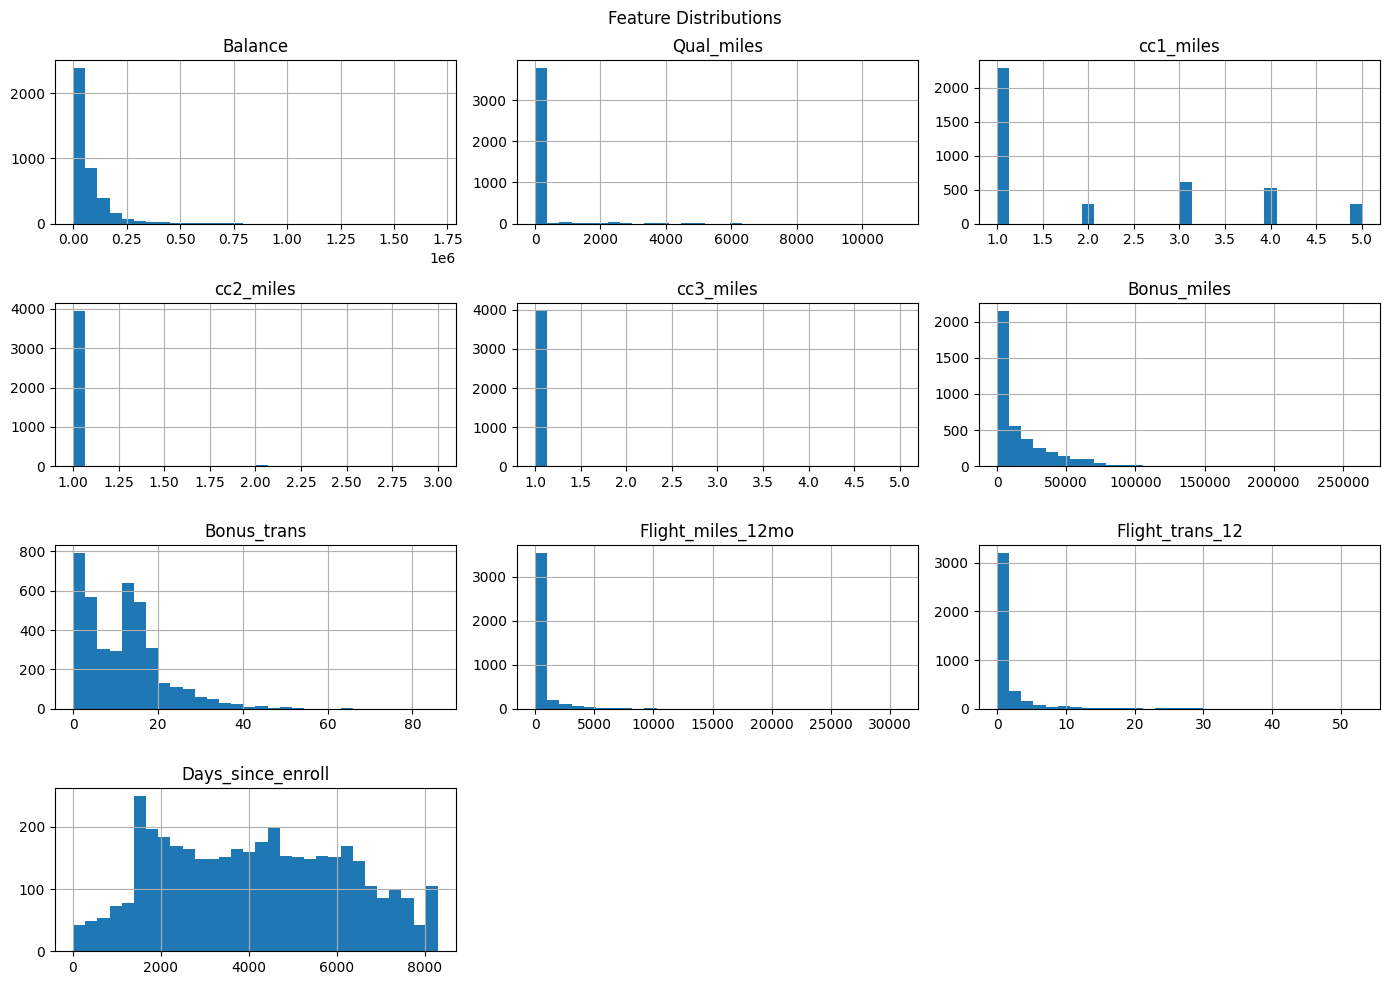

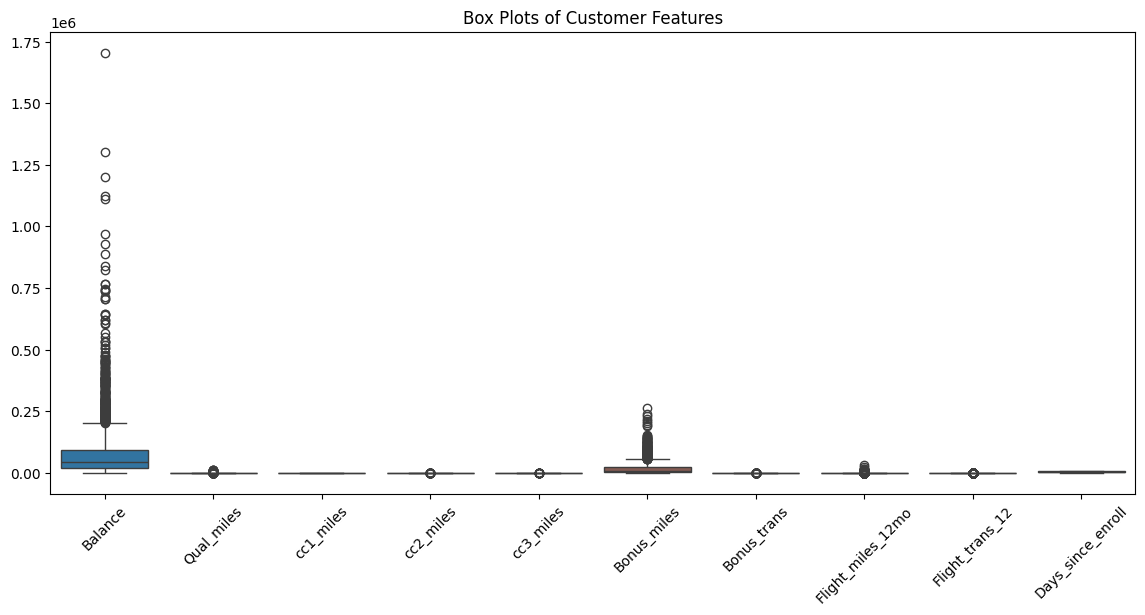

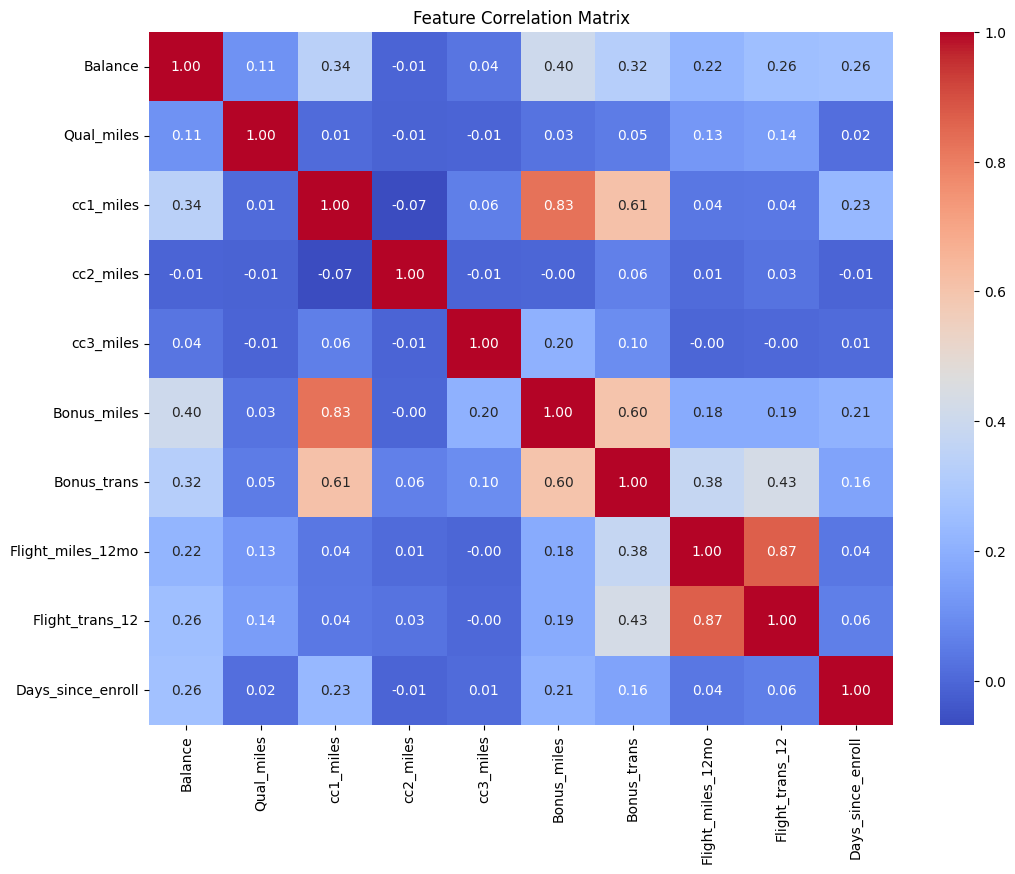

In [25]:

features.hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=features)
plt.title("Box Plots of Customer Features")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(features.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

**Data Preprocessing**

In [26]:

X = df.drop(columns=["ID#", "Award?"]).copy()

X = X.replace([np.inf, -np.inf], np.nan)

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features Used for Clustering:")
print(X.columns.tolist())
print("\nShape After Preprocessing:", X_scaled.shape)
print("\nMissing Values After Preprocessing:", np.isnan(X_scaled).sum())

Features Used for Clustering:
['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

Shape After Preprocessing: (3999, 10)

Missing Values After Preprocessing: 0


**K-Means Elbow Analysis**

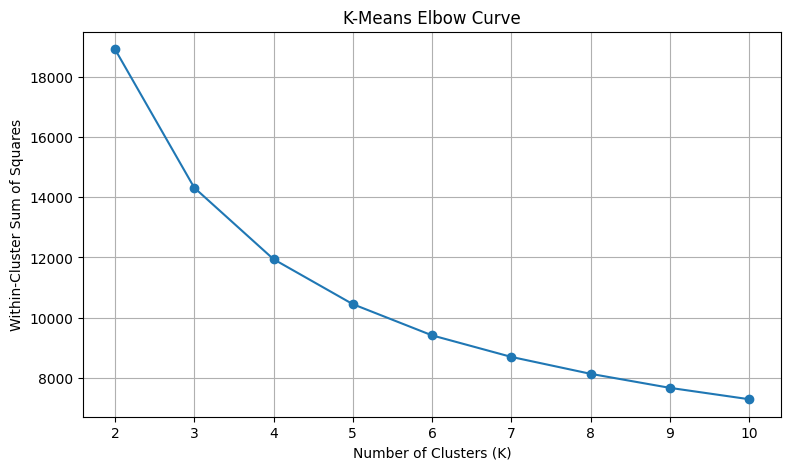

In [27]:

k_values = range(2, 11)
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("K-Means Elbow Curve")
plt.xticks(list(k_values))
plt.grid()
plt.show()

**K-Means Clustering**

In [28]:

silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_values.append(silhouette_score(X_scaled, labels))

best_k = k_values[np.argmax(silhouette_values)]

kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X_scaled)

print("Best K:", best_k)
print("K-Means Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))

print("\nSilhouette Scores:")
for k, score in zip(k_values, silhouette_values):
    print("K =", k, ":", score)

Best K: 2
K-Means Silhouette Score: 0.3421869984245719

Silhouette Scores:
K = 2 : 0.3421869984245719
K = 3 : 0.34076645351622303
K = 4 : 0.3411776895124208
K = 5 : 0.2695576950704476
K = 6 : 0.26900728438824406
K = 7 : 0.27642988799522883
K = 8 : 0.26841381793045993
K = 9 : 0.2643743102572383
K = 10 : 0.26406107355090036


**K-Means Visualization**

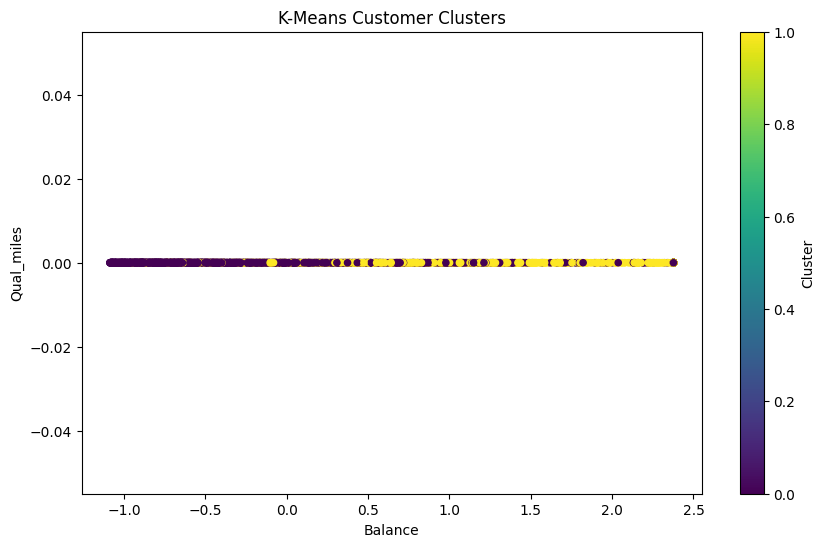

K-Means Cluster Sizes:
KMeans_Cluster
0    2668
1    1331
Name: count, dtype: int64

K-Means Cluster Characteristics:
                      Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                               
0                39884.905079         0.0   1.314843        1.0        1.0   
1               111643.762397         0.0   3.552216        1.0        1.0   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0                5330.847920     7.335082         105.475075         0.366942   
1               35615.935199    19.760331         323.543952         1.041698   

                Days_since_enroll  
KMeans_Cluster                     
0                     3702.912294  
1                     4951.727273  


In [29]:

plt.figure(figsize=(10, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=20
)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("K-Means Customer Clusters")
plt.colorbar(label="Cluster")
plt.show()

cluster_summary = X.copy()
cluster_summary["KMeans_Cluster"] = kmeans_labels

print("K-Means Cluster Sizes:")
print(cluster_summary["KMeans_Cluster"].value_counts().sort_index())

print("\nK-Means Cluster Characteristics:")
print(cluster_summary.groupby("KMeans_Cluster").mean())

**DBSCAN Parameter Analysis**

In [30]:

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [5, 10, 15]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters >= 2:
            non_noise = labels != -1
            score = silhouette_score(X_scaled[non_noise], labels[non_noise])
        else:
            score = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette_score": score
        })

dbscan_results = pd.DataFrame(dbscan_results)

print(dbscan_results)

    eps  min_samples  clusters  noise_points  silhouette_score
0   0.3            5        24          2441         -0.121922
1   0.3           10         5          2779          0.145926
2   0.3           15         3          2919          0.092497
3   0.5            5        30          1393          0.050282
4   0.5           10         9          1866          0.025469
5   0.5           15         6          2106          0.186528
6   0.7            5        23           789          0.098506
7   0.7           10        13          1145          0.099107
8   0.7           15         9          1430          0.147605
9   1.0            5         6           225          0.113859
10  1.0           10         4           439          0.100445
11  1.0           15         8           618         -0.013969
12  1.5            5         1            11               NaN
13  1.5           10         1            13               NaN
14  1.5           15         1            19           

**DBSCAN Clustering**

In [31]:

valid_results = dbscan_results.dropna(subset=["silhouette_score"])

best_dbscan = valid_results.loc[
    valid_results["silhouette_score"].idxmax()
]

best_eps = best_dbscan["eps"]
best_min_samples = int(best_dbscan["min_samples"])

dbscan_model = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_points = np.sum(dbscan_labels == -1)

print("Best DBSCAN eps:", best_eps)
print("Best DBSCAN min_samples:", best_min_samples)
print("Number of Clusters:", n_dbscan_clusters)
print("Noise Points:", noise_points)

if n_dbscan_clusters >= 2:
    non_noise = dbscan_labels != -1
    print(
        "DBSCAN Silhouette Score:",
        silhouette_score(X_scaled[non_noise], dbscan_labels[non_noise])
    )
else:
    print("Silhouette Score cannot be calculated because fewer than 2 clusters were formed.")

Best DBSCAN eps: 0.5
Best DBSCAN min_samples: 15
Number of Clusters: 6
Noise Points: 2106
DBSCAN Silhouette Score: 0.18652795522975915


**DBSCAN Visualization**

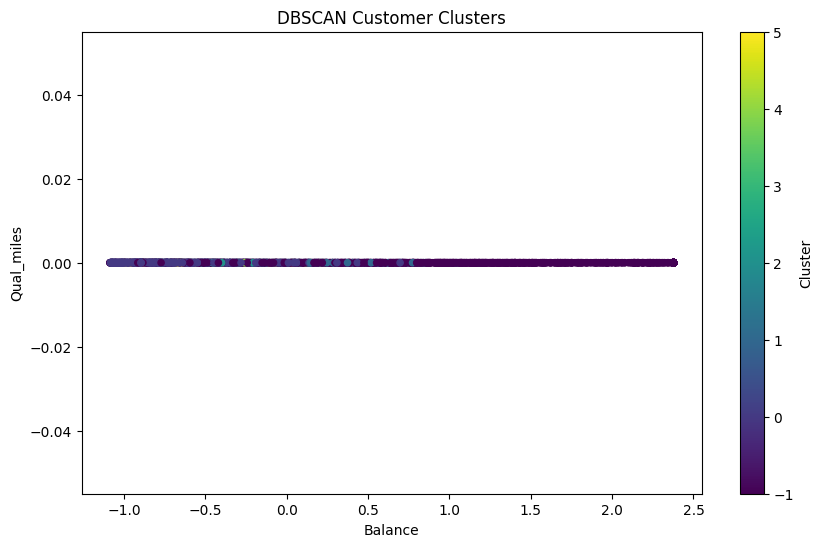

DBSCAN Cluster Distribution:
-1    2106
 0    1415
 1     286
 2     102
 3      21
 4      37
 5      32
Name: count, dtype: int64


In [32]:

plt.figure(figsize=(10, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=20
)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("DBSCAN Customer Clusters")
plt.colorbar(label="Cluster")
plt.show()

print("DBSCAN Cluster Distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

**Clustering Comparison**

  Algorithm  Clusters  Silhouette Score
0   K-Means         2          0.342187
1    DBSCAN         6          0.186528


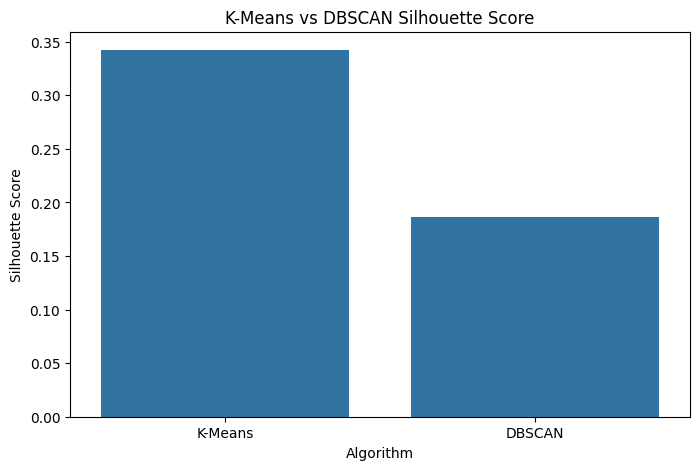

In [33]:

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

if n_dbscan_clusters >= 2:
    dbscan_non_noise = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(
        X_scaled[dbscan_non_noise],
        dbscan_labels[dbscan_non_noise]
    )
else:
    dbscan_silhouette = np.nan

comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Clusters": [best_k, n_dbscan_clusters],
    "Silhouette Score": [kmeans_silhouette, dbscan_silhouette]
})

print(comparison)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x="Algorithm", y="Silhouette Score")
plt.title("K-Means vs DBSCAN Silhouette Score")
plt.ylabel("Silhouette Score")
plt.show()

##**Cluster Analysis and Interpretation**
**K-Means:** K-Means divides customers into a predefined number of clusters based on similarity. The cluster characteristics can be understood by comparing the mean values of the customer features within each cluster.

**DBSCAN:** DBSCAN groups points based on density and can identify noise or outlier observations that do not belong to dense clusters. The eps and min_samples parameters control the density requirements.

The cluster sizes and feature means printed in the previous cells should be used to describe the characteristics of each generated cluster. This directly satisfies the requirement to analyze and interpret the clusters.

##**Conclusion and Insights**

* K-Means and DBSCAN provide different approaches to customer clustering. K-Means is suitable when relatively compact clusters are expected and the number of clusters can be selected using the elbow curve and silhouette score.

* DBSCAN is useful when clusters may have irregular shapes and when identifying noise points is important. Its performance depends strongly on eps and min_samples.

* The final algorithm should be selected based on the clustering structure, silhouette score, number and characteristics of clusters, and the practical meaning of the customer segments.